# Customer Churn Prediction with KNN

**Part 2: Unguided Exercise — sklearn Model Training + Evaluation**  
**Author:** Sergii Rostovskyi

### Objective
Build and evaluate a K-Nearest Neighbors (KNN) classifier that predicts whether a telecommunications customer will churn. The workflow follows the lab requirements: load and explore the data, preprocess it, split it into training/testing sets, train KNN, evaluate it, compare several values of `k`, and translate the findings into business recommendations.

> **Dataset note:** the supplied file has an `.xls` extension, but its contents are comma-separated text. Therefore it is intentionally loaded with `pandas.read_csv()`.

## 1. Load and Explore the Data

I first load the dataset and inspect its dimensions, columns, data types, missing values, and target distribution. I also check `TotalCharges` separately because text-formatted numeric columns can contain blank strings that `isna()` does not initially detect.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# The supplied file is CSV-formatted despite the .xls extension.
candidate_paths = [
    Path("WA_Fn-UseC_-Telco-Customer-Churn.xls"),
    Path("WA_Fn-UseC_-Telco-Customer-Churn.csv"),
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "Dataset not found. Put WA_Fn-UseC_-Telco-Customer-Churn.xls "
        "(or .csv) in the same folder as this notebook."
    )

df = pd.read_csv(data_path)
print(f"Loaded: {data_path}")
print(f"Dataset shape: {df.shape}")
df.head()

Loaded: WA_Fn-UseC_-Telco-Customer-Churn.xls
Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


In [2]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values detected before conversion:")
print(df.isna().sum()[df.isna().sum() > 0])

blank_total_charges = df["TotalCharges"].astype(str).str.strip().eq("").sum()
print(f"\nBlank strings in TotalCharges: {blank_total_charges}")

print("\nTarget distribution:")
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True).mul(100)
print(pd.DataFrame({"count": churn_counts, "percent": churn_pct}))

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing values detected before conversion:
Series([

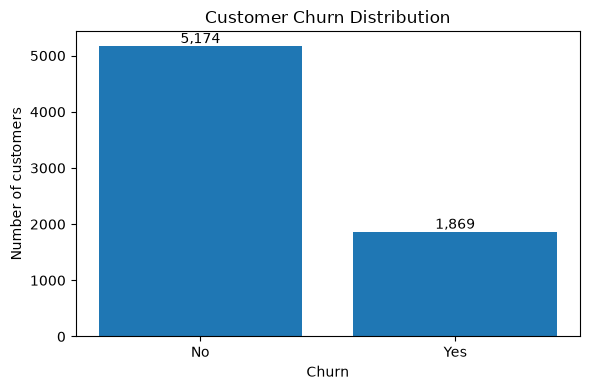

In [3]:
# Target distribution visualization
churn_order = ["No", "Yes"]
counts = df["Churn"].value_counts().reindex(churn_order)

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values)
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of customers")
for i, value in enumerate(counts.values):
    plt.text(i, value + 50, f"{value:,}", ha="center")
plt.tight_layout()
plt.savefig("data_exploration_and_preprocessing.png", dpi=150, bbox_inches="tight")
plt.show()

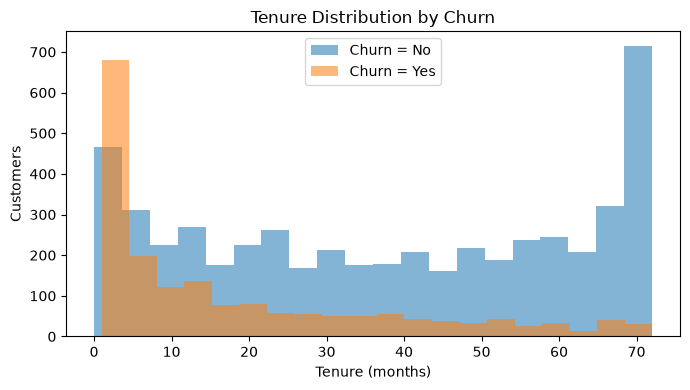

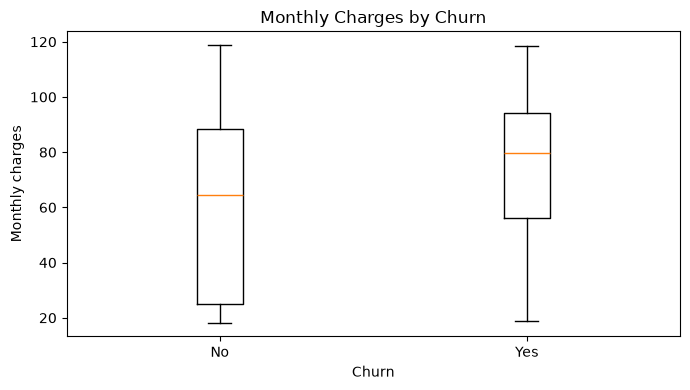

In [4]:
# Two numeric features that are easy to interpret in relation to churn.
plt.figure(figsize=(7, 4))
for churn_value in ["No", "Yes"]:
    plt.hist(
        df.loc[df["Churn"] == churn_value, "tenure"],
        bins=20,
        alpha=0.55,
        label=f"Churn = {churn_value}",
    )
plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (months)")
plt.ylabel("Customers")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
monthly_no = df.loc[df["Churn"] == "No", "MonthlyCharges"]
monthly_yes = df.loc[df["Churn"] == "Yes", "MonthlyCharges"]
plt.boxplot([monthly_no, monthly_yes], tick_labels=["No", "Yes"])
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly charges")
plt.tight_layout()
plt.show()

### Exploration observations

The target is imbalanced: most customers did **not** churn. This means accuracy alone can be misleading, so precision and especially recall for the churn class must also be evaluated. The distributions also suggest that tenure and monthly charges may be associated with churn.

## 2. Data Preprocessing

Preprocessing decisions:

- Convert `TotalCharges` from text to numeric. Blank strings become missing values.
- Fill the 11 missing `TotalCharges` values with the median rather than dropping customers.
- Drop `customerID` because it is an identifier rather than a meaningful predictive feature.
- Map `Churn` from `Yes/No` to `1/0`.
- One-hot encode categorical predictors with `pd.get_dummies()`.
- Scale numeric features after the train/test split. KNN uses distances, so variables with large numeric ranges can otherwise dominate the distance calculation.

In [5]:
model_df = df.copy()

# Convert TotalCharges to numeric. Blank strings become NaN.
model_df["TotalCharges"] = pd.to_numeric(model_df["TotalCharges"], errors="coerce")
missing_total_charges = model_df["TotalCharges"].isna().sum()
median_total_charges = model_df["TotalCharges"].median()
model_df["TotalCharges"] = model_df["TotalCharges"].fillna(median_total_charges)

# Remove identifier and convert target to binary.
model_df = model_df.drop(columns=["customerID"])
model_df["Churn"] = model_df["Churn"].map({"No": 0, "Yes": 1})

X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

# One-hot encode categorical predictors.
X_encoded = pd.get_dummies(X, drop_first=False, dtype=int)

print(f"Missing TotalCharges values filled: {missing_total_charges}")
print(f"Median used for TotalCharges: {median_total_charges:.2f}")
print(f"Encoded feature matrix shape: {X_encoded.shape}")
print(f"Target values: {sorted(y.unique())}")
X_encoded.head()

Missing TotalCharges values filled: 11
Median used for TotalCharges: 1397.47
Encoded feature matrix shape: (7043, 45)
Target values: [np.int64(0), np.int64(1)]


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.850,29.850,1,0,0,1,1,0,1,0,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0
1,0,34,56.950,1889.500,0,1,1,0,1,0,0,1,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,1
2,0,2,53.850,108.150,0,1,1,0,1,0,0,1,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1
3,0,45,42.300,1840.750,0,1,1,0,1,0,1,0,0,1,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,1,0,1,0,1,0,0,0
4,0,2,70.700,151.650,1,0,1,0,1,0,0,1,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0


## 3. Split the Data

The lab specifies an 80/20 split, `random_state=42`, and stratification so the churn ratio remains similar in the training and test sets.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")
print(f"Training churn rate: {y_train.mean():.3%}")
print(f"Test churn rate:     {y_test.mean():.3%}")

# Scale only continuous / numeric columns and fit the scaler ONLY on training data
# to avoid leaking information from the test set.
numeric_columns = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test_scaled[numeric_columns] = scaler.transform(X_test[numeric_columns])

Training set: 5,634 rows
Test set:     1,409 rows
Training churn rate: 26.535%
Test churn rate:     26.544%


## 4. Train the Initial KNN Model (`k = 5`)

In [7]:
knn_5 = KNeighborsClassifier(n_neighbors=5)
knn_5.fit(X_train_scaled, y_train)

pred_5 = knn_5.predict(X_test_scaled)

print(f"Accuracy:  {accuracy_score(y_test, pred_5):.3f}")
print(f"Precision: {precision_score(y_test, pred_5):.3f}")
print(f"Recall:    {recall_score(y_test, pred_5):.3f}")
print(f"F1 score:  {f1_score(y_test, pred_5):.3f}")

Accuracy:  0.764
Precision: 0.553
Recall:    0.575
F1 score:  0.564


## 5. Make Predictions and Evaluate

The confusion matrix is organized as:

`[[true negatives, false positives], [false negatives, true positives]]`

For churn, false negatives are especially important because they are customers who actually churn but were predicted as non-churners.

In [8]:
cm_5 = confusion_matrix(y_test, pred_5)
print("Confusion matrix for k=5:")
print(cm_5)
print("\nClassification report for k=5:")
print(classification_report(y_test, pred_5, target_names=["No Churn", "Churn"]))

Confusion matrix for k=5:
[[861 174]
 [159 215]]

Classification report for k=5:
              precision    recall  f1-score   support

    No Churn       0.84      0.83      0.84      1035
       Churn       0.55      0.57      0.56       374

    accuracy                           0.76      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.77      0.76      0.77      1409



## 6. Experiment with Different K Values

The required values are `1, 3, 5, 7, 9, 11, 15`. I compare accuracy, precision, recall, and F1. F1 is included as an additional balanced summary of precision and recall.

In [9]:
k_values = [1, 3, 5, 7, 9, 11, 15]
results = []
models = {}

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    models[k] = model

    results.append({
        "k": k,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
    })

results_df = pd.DataFrame(results).set_index("k")
results_df

,accuracy,precision,recall,f1
k,,,,
1,0.734,0.499,0.513,0.506
3,0.754,0.535,0.553,0.544
5,0.764,0.553,0.575,0.564
7,0.764,0.554,0.572,0.563
9,0.780,0.586,0.586,0.586
11,0.778,0.582,0.578,0.580
15,0.778,0.584,0.567,0.575


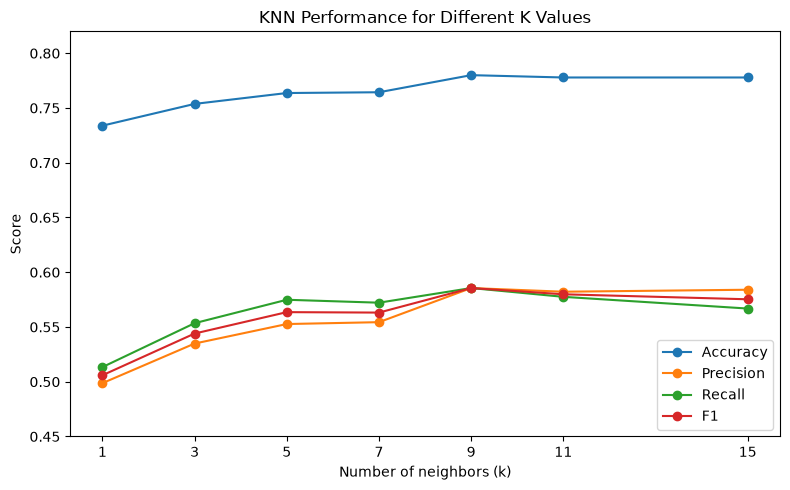

Best k by F1 score: 9
accuracy    0.780
precision   0.586
recall      0.586
f1          0.586
Name: 9, dtype: float64


In [10]:
plt.figure(figsize=(8, 5))
for metric in ["accuracy", "precision", "recall", "f1"]:
    plt.plot(results_df.index, results_df[metric], marker="o", label=metric.capitalize())
plt.title("KNN Performance for Different K Values")
plt.xlabel("Number of neighbors (k)")
plt.ylabel("Score")
plt.xticks(k_values)
plt.ylim(0.45, 0.82)
plt.legend()
plt.tight_layout()
plt.savefig("comparison_of_different_k_values.png", dpi=150, bbox_inches="tight")
plt.show()

best_k = int(results_df["f1"].idxmax())
print(f"Best k by F1 score: {best_k}")
print(results_df.loc[best_k])

In [11]:
# Final evaluation for the selected k.
best_model = models[best_k]
best_pred = best_model.predict(X_test_scaled)
best_cm = confusion_matrix(y_test, best_pred)

print(f"Selected model: KNN with k={best_k}")
print(f"Accuracy:  {accuracy_score(y_test, best_pred):.3f}")
print(f"Precision: {precision_score(y_test, best_pred):.3f}")
print(f"Recall:    {recall_score(y_test, best_pred):.3f}")
print(f"F1 score:  {f1_score(y_test, best_pred):.3f}")
print("\nClassification report:")
print(classification_report(y_test, best_pred, target_names=["No Churn", "Churn"]))

print("Confusion matrix:")
print(best_cm)

Selected model: KNN with k=9
Accuracy:  0.780
Precision: 0.586
Recall:    0.586
F1 score:  0.586

Classification report:
              precision    recall  f1-score   support

    No Churn       0.85      0.85      0.85      1035
       Churn       0.59      0.59      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

Confusion matrix:
[[880 155]
 [155 219]]


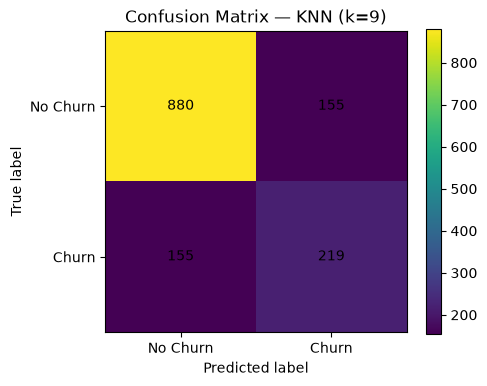

In [12]:
# Visualize confusion matrix without external plotting libraries.
plt.figure(figsize=(5, 4))
plt.imshow(best_cm)
plt.title(f"Confusion Matrix — KNN (k={best_k})")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, best_cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.savefig("model_training_and_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Analysis of Churn Patterns and Business Recommendations

KNN does not provide built-in feature importance scores. Instead of claiming causal importance, I explore **associations** between individual features and churn through churn rates and correlations. These patterns are useful for interpretation, but they do not prove that a feature causes churn.

In [13]:
def churn_rate_table(column):
    return (
        df.assign(ChurnFlag=df["Churn"].eq("Yes").astype(int))
          .groupby(column)["ChurnFlag"]
          .agg(["mean", "count"])
          .rename(columns={"mean": "churn_rate"})
          .sort_values("churn_rate", ascending=False)
    )

for column in ["Contract", "InternetService", "PaymentMethod"]:
    print(f"\nChurn rate by {column}:")
    display(churn_rate_table(column))


Churn rate by Contract:


,churn_rate,count
Contract,,
Month-to-month,0.427,3875
One year,0.113,1473
Two year,0.028,1695



Churn rate by InternetService:


,churn_rate,count
InternetService,,
Fiber optic,0.419,3096
DSL,0.190,2421
No,0.074,1526



Churn rate by PaymentMethod:


,churn_rate,count
PaymentMethod,,
Electronic check,0.453,2365
Mailed check,0.191,1612
Bank transfer (automatic),0.167,1544
Credit card (automatic),0.152,1522


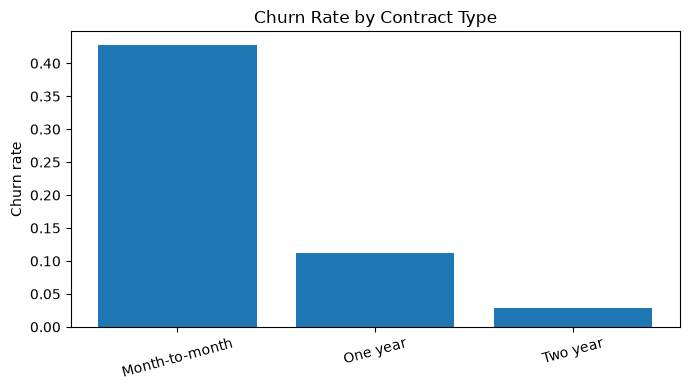

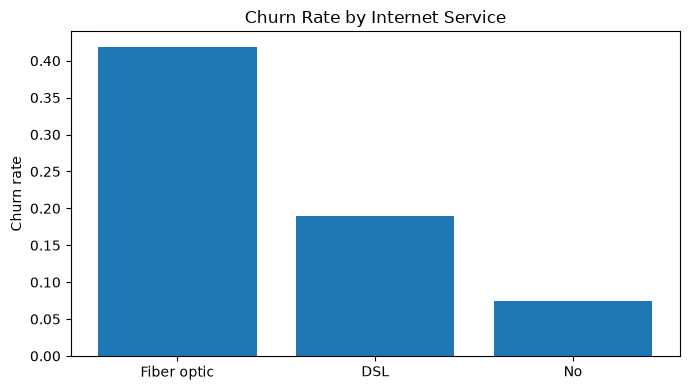

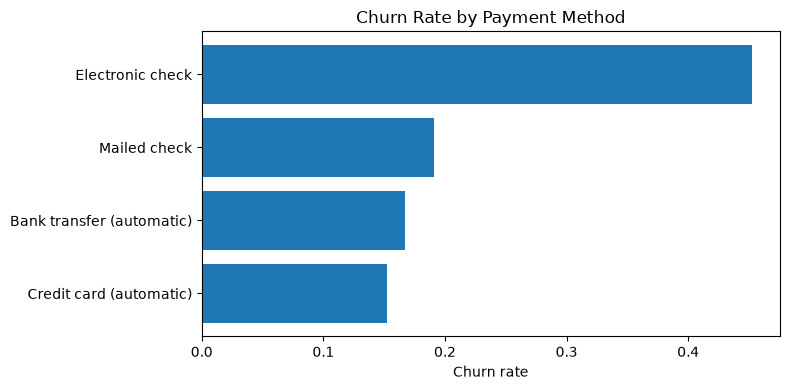

In [14]:
# Visualize churn rates for three interpretable categorical features.
contract_rates = churn_rate_table("Contract")["churn_rate"].sort_values(ascending=False)
plt.figure(figsize=(7, 4))
plt.bar(contract_rates.index, contract_rates.values)
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn rate")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

internet_rates = churn_rate_table("InternetService")["churn_rate"].sort_values(ascending=False)
plt.figure(figsize=(7, 4))
plt.bar(internet_rates.index, internet_rates.values)
plt.title("Churn Rate by Internet Service")
plt.ylabel("Churn rate")
plt.tight_layout()
plt.show()

payment_rates = churn_rate_table("PaymentMethod")["churn_rate"].sort_values(ascending=True)
plt.figure(figsize=(8, 4))
plt.barh(payment_rates.index, payment_rates.values)
plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn rate")
plt.tight_layout()
plt.show()

In [15]:
# Correlation is used only as an exploratory association measure.
correlation_data = pd.concat([X_encoded, y.rename("Churn")], axis=1)
churn_corr = (
    correlation_data.corr(numeric_only=True)["Churn"]
    .drop("Churn")
    .sort_values()
)

print("Features most negatively associated with churn:")
display(churn_corr.head(10).to_frame("correlation"))

print("Features most positively associated with churn:")
display(churn_corr.tail(10).sort_values(ascending=False).to_frame("correlation"))

Features most negatively associated with churn:


,correlation
tenure,-0.352
Contract_Two year,-0.302
StreamingTV_No internet service,-0.228
OnlineBackup_No internet service,-0.228
DeviceProtection_No internet service,-0.228
InternetService_No,-0.228
OnlineSecurity_No internet service,-0.228
TechSupport_No internet service,-0.228
StreamingMovies_No internet service,-0.228
TotalCharges,-0.199


Features most positively associated with churn:


,correlation
Contract_Month-to-month,0.405
OnlineSecurity_No,0.343
TechSupport_No,0.337
InternetService_Fiber optic,0.308
PaymentMethod_Electronic check,0.302
OnlineBackup_No,0.268
DeviceProtection_No,0.252
MonthlyCharges,0.193
PaperlessBilling_Yes,0.192
Dependents_No,0.164


In [16]:
# Helpful context: a majority-class baseline.
majority_baseline = max(y_test.mean(), 1 - y_test.mean())
model_accuracy = accuracy_score(y_test, best_pred)

print(f"Majority-class accuracy baseline: {majority_baseline:.3%}")
print(f"Selected KNN accuracy:           {model_accuracy:.3%}")
print(f"Improvement over baseline:       {(model_accuracy - majority_baseline):.3%}")

# Exact confusion-matrix counts for interpretation.
tn, fp, fn, tp = best_cm.ravel()
print(f"\nTrue negatives:  {tn}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}")
print(f"True positives:  {tp}")

Majority-class accuracy baseline: 73.456%
Selected KNN accuracy:           77.999%
Improvement over baseline:       4.542%

True negatives:  880
False positives: 155
False negatives: 155
True positives:  219


### Final findings

- Among the required values, **`k = 9`** gives the strongest overall balance on this split.
- The selected model reaches about **78% accuracy**. Because only about 26.5% of customers churn, the majority-class baseline is already about 73.5%, so accuracy must not be interpreted by itself.
- Precision and recall for churn are both about **58.6%**. In the test set, the model correctly identifies 219 churners but misses 155 churners.
- The clearest exploratory churn patterns are associated with **month-to-month contracts**, **fiber-optic internet**, **electronic-check payments**, **shorter tenure**, lack of **online security/tech support**, and higher monthly charges.

### Business recommendations

1. Prioritize retention outreach toward customers on month-to-month contracts, especially newer customers and customers using fiber-optic service.
2. Investigate why electronic-check users and customers without online security/technical support show higher churn rates; these groups may benefit from targeted onboarding or service bundles.
3. Use the model as a screening tool rather than an automatic decision system. Customers flagged as high risk can be passed to a retention workflow for further review.
4. For a real business deployment, optimize primarily for churn recall and expected retention value/cost rather than accuracy alone.

### Limitations and future improvements

- The data is imbalanced, and KNN still misses a substantial share of churners.
- KNN does not provide native feature-importance explanations, and the associations above are not causal conclusions.
- The current result is based on one train/test split; cross-validation would provide a more robust estimate.
- Future work should compare KNN with models such as Logistic Regression, Random Forest, or gradient boosting, and should evaluate ROC-AUC / Precision-Recall metrics and probability thresholds.
- Business costs should be included: missing a real churner and contacting a non-churner have different financial consequences.